# Customer Churn Analysis — Telecom Industry
## Exploratory Data Analysis (EDA)
---

## Problem Statement

A telecom company is experiencing a high customer churn rate and does not have clarity on who is leaving, why they are leaving, and how much revenue is being lost as a result.

Acquiring a new customer costs 5 times more than retaining an existing one. Without understanding what drives churn, the company cannot take any meaningful action — leading to continuous and preventable revenue loss.

Using historical customer data, this project performs a complete Exploratory Data Analysis to identify the key factors behind churn, measure the revenue impact, and suggest practical steps the business can take to retain more customers.

## Objectives

- Understand the overall churn rate and assess how serious it is for the business
- Find out which customer segments are most likely to churn
- Investigate whether customer complaints are driving churn
- Compare usage behavior between customers who stayed and those who left
- Calculate the total revenue the company has lost due to churn
- Identify unusual data points that could indicate fraud, VIP customers, or data errors
- Provide clear and actionable recommendations the business can act on

## Dataset Details

- Source: Telecom Customer Churn Dataset
- Raw rows before cleaning: 3,157
- Clean rows after removing nulls and duplicates: 2,851
- Total columns after dropping the ID column: 13
- Target variable: Churn (0 means the customer stayed, 1 means the customer left)

---
## Step 1: Import Libraries

Loading the libraries needed for data manipulation, analysis, and visualization before we begin working with the dataset.

In [84]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

---
## Step 2: Load the Dataset

Reading the CSV file into a DataFrame and taking a first look at its shape, structure, and what columns are available.

In [85]:
cc = pd.read_csv(r"C:\Users\kousi\Downloads\Data Sets\Churn_Dateset_new.csv")

In [86]:
# Preview the first 5 rows to understand the structure and available columns
cc.head()

,Anonymous Customer ID,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Churn,Customer Value
0,1.0,8.0,0.0,38.0,0.0,4370.0,71.0,5.0,17.0,3.0,1.0,1.0,0.0,132.60
1,2.0,0.0,0.0,39.0,0.0,318.0,5.0,7.0,4.0,2.0,1.0,2.0,0.0,17.46
2,3.0,10.0,0.0,37.0,0.0,2453.0,60.0,359.0,24.0,3.0,1.0,1.0,0.0,181.29
3,4.0,10.0,0.0,38.0,0.0,4198.0,66.0,1.0,35.0,1.0,1.0,1.0,0.0,252.48
4,5.0,3.0,0.0,38.0,0.0,2393.0,58.0,2.0,33.0,1.0,1.0,1.0,0.0,144.78


In [87]:
# Check the number of rows and columns in the dataset
cc.shape

(3157, 14)

In [88]:
# Check column names, data types, and how many non-null values exist per column
cc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3157 entries, 0 to 3156
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Anonymous Customer ID    3150 non-null   float64
 1   Call  Failure            3150 non-null   float64
 2   Complains                3150 non-null   float64
 3   Subscription  Length     3150 non-null   float64
 4   Charge  Amount           3150 non-null   float64
 5   Seconds of Use           3150 non-null   float64
 6   Frequency of use         3150 non-null   float64
 7   Frequency of SMS         3150 non-null   float64
 8   Distinct Called Numbers  3150 non-null   float64
 9   Age Group                3150 non-null   float64
 10  Tariff Plan              3150 non-null   float64
 11  Status                   3150 non-null   float64
 12  Churn                    3150 non-null   float64
 13  Customer Value           3150 non-null   float64
dtypes: float64(14)
memory us

---
## Step 3: Check Missing Values

Before cleaning anything, we need to understand where the gaps are and how many values are missing in each column.

In [89]:
# Show only columns that have at least one missing value
# isnull() marks each cell True or False, sum() counts the Trues, and [>0] filters only affected columns
cc.isnull().sum()[cc.isnull().sum()>0]

Anonymous Customer ID      7
Call  Failure              7
Complains                  7
Subscription  Length       7
Charge  Amount             7
Seconds of Use             7
Frequency of use           7
Frequency of SMS           7
Distinct Called Numbers    7
Age Group                  7
Tariff Plan                7
Status                     7
Churn                      7
Customer Value             7
dtype: int64

### Finding:

Every column has exactly 7 missing values. This tells us that 7 entire rows are completely blank, not that random individual values are missing across the dataset. These rows carry no useful information at all. The plan is to fill numerical columns using the mean and categorical columns using the mode, which is the most frequently occurring value.

---
## Step 4: Data Cleaning

Removing columns that add no value to the analysis, filling in the missing values using the right strategy for each column type, and then removing any duplicate rows that could distort our results.

In [90]:
# Drop the ID column since it is just a row label and carries no analytical meaning
# Fill each column's missing values with the column mean
# For the Churn column specifically, we use mode since it only takes values 0 or 1
cc = cc.drop(columns = ['Anonymous Customer ID'])
cc['Call  Failure'].fillna(cc['Call  Failure'].mean(), inplace=True)
cc['Complains'].fillna(cc['Complains'].mean(), inplace=True)
cc['Subscription  Length'].fillna(cc['Subscription  Length'].mean(), inplace=True)
cc['Charge  Amount'].fillna(cc['Charge  Amount'].mean(), inplace=True)
cc['Seconds of Use'].fillna(cc['Seconds of Use'].mean(), inplace=True)
cc['Frequency of use'].fillna(cc['Frequency of use'].mean(), inplace=True)
cc['Frequency of SMS'].fillna(cc['Frequency of SMS'].mean(), inplace=True)
cc['Distinct Called Numbers'].fillna(cc['Distinct Called Numbers'].mean(), inplace=True)
cc['Age Group'].fillna(cc['Age Group'].mean(), inplace=True)
cc['Tariff Plan'].fillna(cc['Tariff Plan'].mean(), inplace=True)
cc['Status'].fillna(cc['Status'].mean(), inplace=True)
cc['Churn'].fillna(cc['Churn'].mode(), inplace=True)
cc['Customer Value'].fillna(cc['Customer Value'].mean(), inplace=True)

In [91]:
# Quick check to confirm the dataset looks correct after filling missing values
cc.head(2)

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Churn,Customer Value
0,8.0,0.0,38.0,0.0,4370.0,71.0,5.0,17.0,3.0,1.0,1.0,0.0,132.60
1,0.0,0.0,39.0,0.0,318.0,5.0,7.0,4.0,2.0,1.0,2.0,0.0,17.46


In [92]:
# Count how many duplicate rows exist in the dataset before removing them
cc.duplicated().sum()

np.int64(306)

In [93]:
# Remove all duplicate rows so they do not skew any of our charts or calculations
cc.drop_duplicates(inplace=True)

In [94]:
# Confirm that no duplicates remain
cc.duplicated().sum()

np.int64(0)

In [95]:
# Check the final shape of the clean dataset
cc.shape

(2851, 13)

### Finding:

306 duplicate rows were found and removed, which was nearly 10 percent of the original dataset. Keeping them would have inflated counts and made every chart misleading. After cleaning, the dataset contains 2,851 rows and 13 columns and is now ready for analysis.

---
## Step 5: Churn Overview

The first thing any analyst checks is the overall churn rate. This gives us the big picture before we start digging into the reasons.

H0: The churn rate is within an acceptable range, below 5 percent.

H1: The churn rate is high enough to be a serious concern for the business.

In [96]:
# Count of customers in each category — 0 means retained, 1 means churned
churn_count = cc.Churn.value_counts()
churn_count

Churn
0.0    2404
1.0     446
Name: count, dtype: int64

In [97]:
# Convert counts to percentages — normalize divides each count by the total, then multiply by 100
churn_percentage = cc.Churn.value_counts(normalize= True)*100
churn_percentage

Churn
0.0    84.350877
1.0    15.649123
Name: proportion, dtype: float64

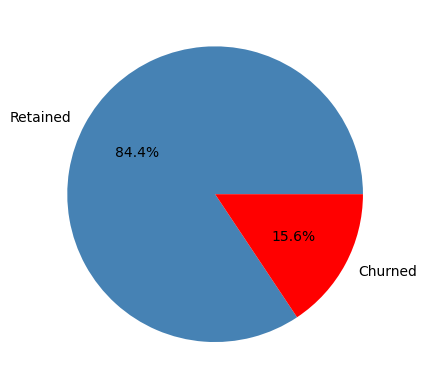

In [98]:
# Pie chart to visualize the split between retained and churned customers
# autopct shows the percentage value on each slice with one decimal place
plt.pie(churn_count.values, colors = ['steelblue','red'], labels = ['Retained', 'Churned'],   autopct='%1.1f%%');

### Finding:

The churn rate is 15.6 percent, which means roughly 1 in every 6 customers is leaving. This is well above the healthy industry threshold of 5 percent. H0 is rejected. The business is losing customers at an alarming rate and needs to act quickly. This finding sets the urgency for the rest of the analysis — we now need to understand exactly why so many customers are leaving.

---
## Step 6: Complaints vs Churn

Here we check whether customers who raised a complaint are more likely to leave. If a business fails to resolve issues, customers tend to walk away.

H0: Whether a customer complained or not has no impact on whether they churn.

H1: Customers who complained are significantly more likely to churn than those who did not.

In [99]:
# Check the raw numbers — how many churned and retained customers exist in each complaint group
cc.groupby('Complains')['Churn'].value_counts()

Complains  Churn
0.0        0.0      2364
           1.0       256
1.0        1.0       190
           0.0        40
Name: count, dtype: int64

In [100]:
# Cross tabulation gives a clean side-by-side count of churned vs retained for each complaint group
comp_churn = pd.crosstab(cc['Complains'], cc['Churn'])
comp_churn

Churn,0.0,1.0
Complains,,
0.0,2364,256
1.0,40,190


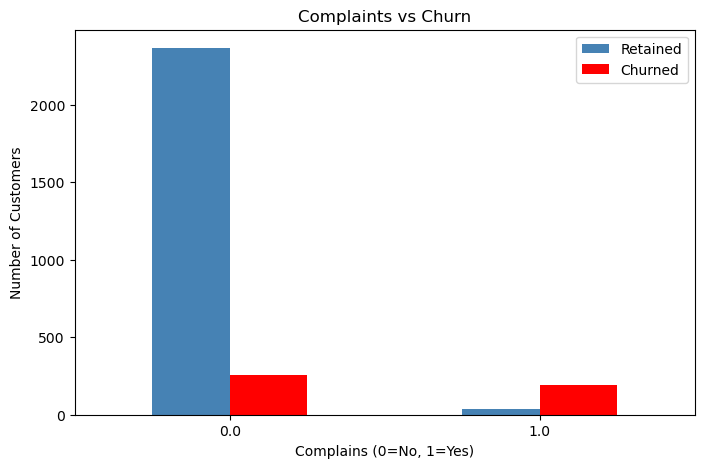

In [101]:
comp_churn.plot(kind='bar',color=['steelblue', 'red'],figsize=(8, 5))

plt.title('Complaints vs Churn')
plt.xlabel('Complains (0=No, 1=Yes)')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.legend(['Retained', 'Churned'])
plt.show()

### Finding:

Among customers who did not complain, only 9.7 percent churned. Among customers who did complain, 82 percent churned. The chart makes this very clear — the red bar completely dominates the complained group on the right side. H0 is rejected. Complaints are the single strongest root cause of churn in this dataset. The business must treat complaint resolution as its top priority because an unresolved complaint almost always results in a lost customer.

---
## Step 7: Age Group vs Churn

Looking at whether certain age groups are more likely to leave than others helps the business target the right customers with retention campaigns.

H0: All age groups experience the same churn rate.

H1: Some age groups churn significantly more than others.

In [102]:
# Cross tabulation of age group against churn status
Age_churn = pd.crosstab(cc['Age Group'], cc['Churn'])
Age_churn

Churn,0.0,1.0
Age Group,,
1.0,112,0
2.0,764,157
3.0,1083,213
4.0,293,74
5.0,152,2


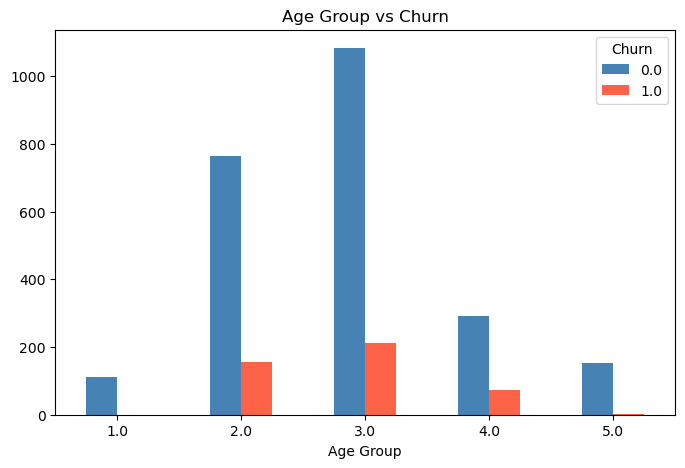

In [103]:
age_churn = pd.crosstab(cc['Age Group'], cc['Churn'])
age_churn.plot(kind='bar', color=['steelblue', 'tomato'], figsize=(8,5))
plt.title('Age Group vs Churn')
plt.xticks(rotation=0)
plt.show()

### Finding:

Age Group 3 has the highest number of churned customers at 213. Age Group 1 has zero churn at all, and Age Group 5 has almost none with only 2 customers leaving. The middle age groups — 2, 3, and 4 — are clearly the most at risk. H0 is rejected. Churn is not evenly distributed across age groups. Retention campaigns would have the most impact if directed specifically at Age Group 3.

---
## Step 8: Tariff Plan vs Churn

If customers on a particular plan are leaving more often, it may signal a problem with pricing, value, or service on that plan.

H0: Customers on all tariff plans churn at the same rate.

H1: Customers on certain tariff plans churn significantly more than others.

In [104]:
# Cross tabulation of tariff plan against churn status
tariff_churn = pd.crosstab(cc['Tariff Plan'], cc['Churn'])
tariff_churn

Churn,0.0,1.0
Tariff Plan,,
1.0,2181,440
2.0,223,6


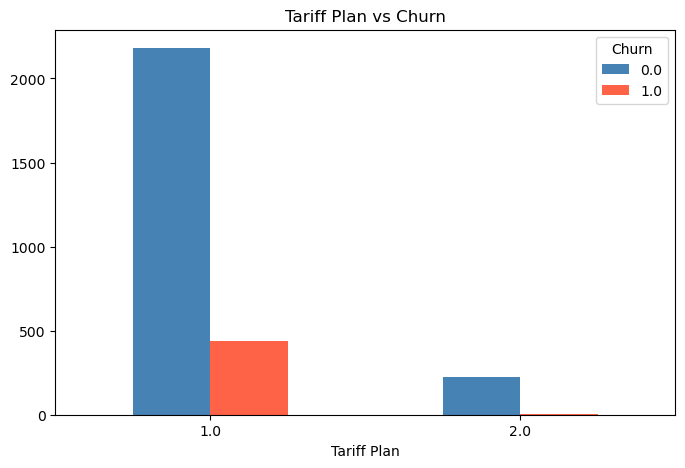

In [105]:
tariff_churn.plot(kind='bar', color=['steelblue', 'tomato'], figsize=(8,5))
plt.title('Tariff Plan vs Churn')
plt.xticks(rotation=0)
plt.show()

### Finding:

Customers on Tariff Plan 1 have a churn rate of 16.8 percent, while customers on Plan 2 have a churn rate of only 2.6 percent. Plan 1 customers are leaving at 6 times the rate of Plan 2 customers. H0 is rejected. The difference is too large to ignore. The business needs to investigate what is wrong with Plan 1 — whether it is the pricing, the benefits, or the overall experience — and take corrective action.

---
## Step 9: Customer Status vs Churn

Status tells us whether a customer is currently active or inactive. Inactive customers have already disengaged from the service, which makes them a high-risk group for churn.

H0: Active and inactive customers churn at the same rate.

H1: Inactive customers are significantly more likely to churn than active ones.

In [106]:
# Cross tabulation of customer status against churn — 1 is active, 2 is inactive
pd.crosstab(cc['Status'], cc['Churn'])

Churn,0.0,1.0
Status,,
1.0,2045,121
2.0,359,325


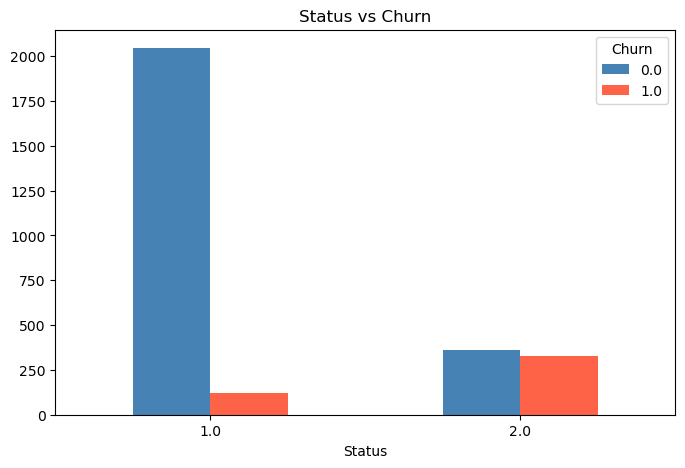

In [107]:
status_churn = pd.crosstab(cc['Status'], cc['Churn'])
status_churn.plot(kind='bar', color=['steelblue', 'tomato'], figsize=(8,5))
plt.title('Status vs Churn')
plt.xticks(rotation=0)
plt.show()

### Finding:

Active customers have a churn rate of just 5.6 percent. Inactive customers have a churn rate of 47.5 percent — nearly half of them are leaving. The chart shows the two bars for Status 2 at almost equal height, which visually captures just how serious this is. H0 is rejected. Inactivity is the strongest single predictor of churn in this entire dataset. If a customer goes inactive, the business has a very short window to bring them back before they leave permanently.

---
## Step 10: Correlation Heatmap

A heatmap gives us a bird's-eye view of how strongly each feature relates to every other feature. It helps confirm the patterns we have already found and highlights any features that carry overlapping information.

In [108]:
# Calculate the correlation between all numerical columns
cc.corr()

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Churn,Customer Value
Call Failure,1.000000,0.149564,0.177206,0.585442,0.495463,0.567096,-0.031926,0.498604,0.049340,0.187537,-0.094090,0.003310,0.359295
Complains,0.149564,1.000000,-0.019229,-0.035887,-0.108934,-0.095519,-0.114729,-0.061314,0.015761,0.002461,0.282928,0.546055,-0.115267
Subscription Length,0.177206,-0.019229,1.000000,0.084275,0.127184,0.109148,0.080530,0.099215,0.030078,-0.160538,0.144235,-0.037984,0.118608
Charge Amount,0.585442,-0.035887,0.084275,1.000000,0.443585,0.372647,0.085781,0.413897,0.282761,0.321193,-0.353311,-0.201662,0.215641
Seconds of Use,0.495463,-0.108934,0.127184,0.443585,1.000000,0.945144,0.093073,0.671973,0.015253,0.127793,-0.449660,-0.295999,0.833861
Frequency of use,0.567096,-0.095519,0.109148,0.372647,0.945144,1.000000,0.090712,0.731204,-0.039523,0.199873,-0.440601,-0.298608,0.812845
Frequency of SMS,-0.031926,-0.114729,0.080530,0.085781,0.093073,0.090712,1.000000,0.069717,-0.056859,0.193785,-0.288049,-0.218894,0.328740
Distinct Called Numbers,0.498604,-0.061314,0.099215,0.413897,0.671973,0.731204,0.069717,1.000000,0.015563,0.167037,-0.393052,-0.270343,0.576318
Age Group,0.049340,0.015761,0.030078,0.282761,0.015253,-0.039523,-0.056859,0.015563,1.000000,-0.153496,0.020048,-0.005891,-0.382044
Tariff Plan,0.187537,0.002461,-0.160538,0.321193,0.127793,0.199873,0.193785,0.167037,-0.153496,1.000000,-0.163083,-0.106000,0.218856


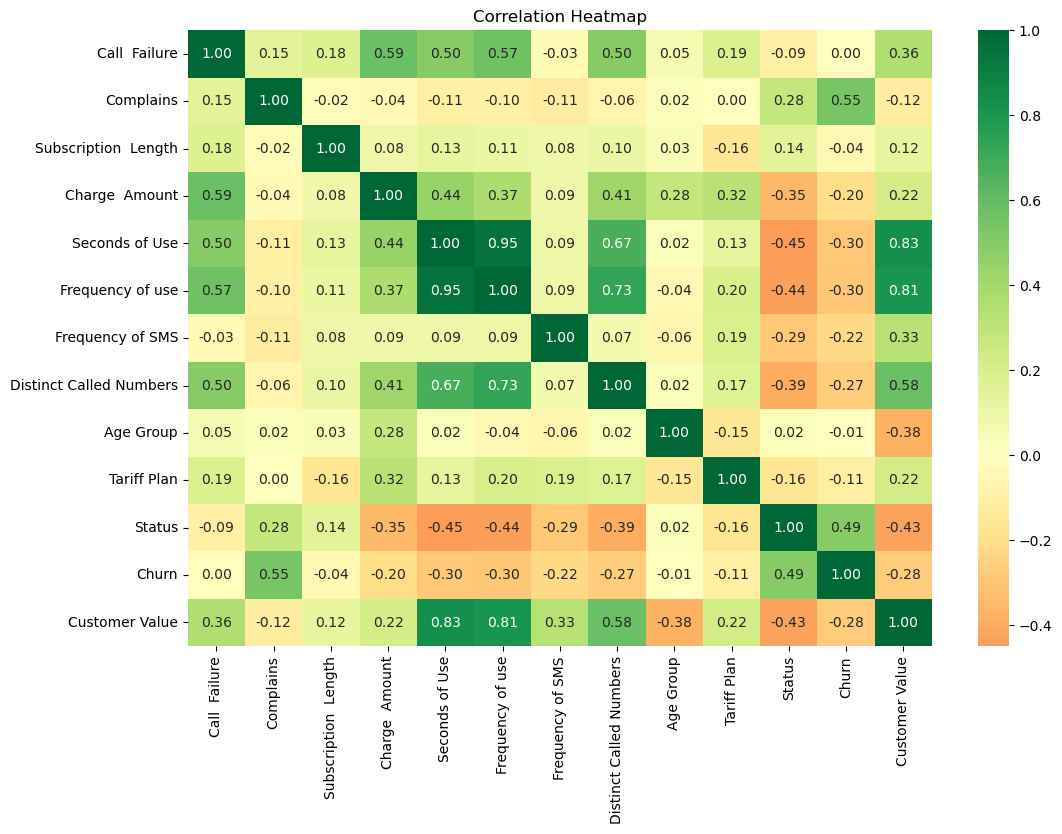

In [109]:
# Visualize correlations as a color-coded heatmap
# annot=True shows the actual number inside each cell
# cmap RdYlGn uses red for negative, yellow for neutral, and green for positive correlations
plt.figure(figsize=(12, 8))
sns.heatmap(cc.corr(), annot=True,    fmt='.2f', cmap='RdYlGn',   center=0)       
plt.title('Correlation Heatmap')
plt.show()

### Finding:

Complaints show the strongest positive correlation with churn at 0.55, which confirms what we saw in the bar chart earlier. Customer Status also has a strong positive correlation with churn at 0.49. On the other side, Seconds of Use, Frequency of Use, and Customer Value all show negative correlations with churn, meaning customers who use the service more tend to stay longer. Seconds of Use and Frequency of Use are almost perfectly correlated with each other at 0.95, which means they carry nearly identical information. The heatmap ties all our individual findings together in a single view.

---
## Step 11: Outlier Detection

Boxplots help us spot values that are unusually far from the rest of the data. In a telecom dataset, outliers could mean a customer is a heavy business user, a VIP account, or could point to a data entry error worth looking into.

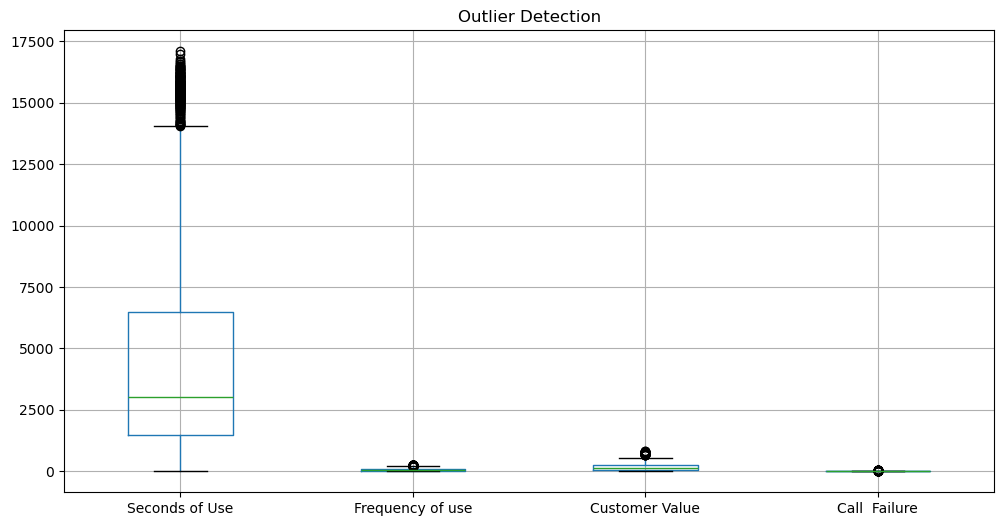

In [110]:
# Boxplot for four key columns — dots appearing outside the whiskers are outliers
plt.figure(figsize=(12, 6))
cc.boxplot(column=['Seconds of Use', 'Frequency of use','Customer Value','Call  Failure'])
plt.title('Outlier Detection')
plt.show()

### Finding:

Seconds of Use has the most extreme outliers, with some customers recorded at over 17,500 seconds while the typical range sits below 6,000. Frequency of Use also has a few unusually high values. Customer Value shows one clearly elevated data point. Call Failure is relatively consistent with no major outliers. The outliers in Seconds of Use are worth a closer look — they could represent business accounts, VIP customers, or simply incorrect data that was entered into the system.

---
## Step 12: Revenue Impact

Knowing how much revenue has been lost to churn puts the problem in financial terms, which is what the business leadership ultimately cares about.

H0: Churned and retained customers have roughly the same customer value.

H1: Churned customers have significantly lower customer value compared to those who stayed.

In [111]:
# Average Customer Value grouped by churn status
cc.groupby('Churn')['Customer Value'].mean()

Churn
0.0    193.338037
1.0     62.296110
Name: Customer Value, dtype: float64

In [112]:
# Total revenue lost — sum of customer value for every customer who churned
churned_value = cc[cc['Churn'] == 1.0]['Customer Value'].sum()
churned_value

np.float64(27784.065)

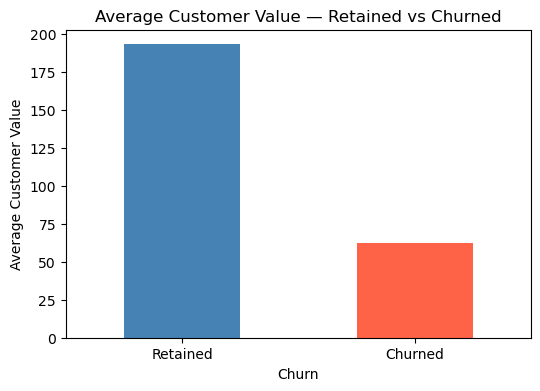

In [113]:
cc.groupby('Churn')['Customer Value'].mean().plot(
    kind='bar',color=['steelblue', 'tomato'],figsize=(6, 4))
plt.title('Average Customer Value — Retained vs Churned')
plt.xticks([0, 1], ['Retained', 'Churned'], rotation=0)
plt.ylabel('Average Customer Value')
plt.show()

### Finding:

Retained customers have an average value of 193.34 while churned customers average only 62.30. Customers who stayed are worth three times more than those who left. The total revenue lost from churn is 27,784. H0 is rejected. Even reducing churn by half would save the business approximately 14,000 in customer value, which makes any investment in retention campaigns well worth it.

---
## Step 13: Call Failures vs Churn

Call failures are a direct measure of service quality. We want to see whether poor network performance is pushing customers to leave.

H0: Customers who experience more call failures are more likely to churn.

H1: Call failures have no significant relationship with churn.

In [114]:
# Average call failures for retained vs churned customers
cc.groupby('Churn')['Call  Failure'].mean()

Churn
0.0    7.792013
1.0    7.858744
Name: Call  Failure, dtype: float64

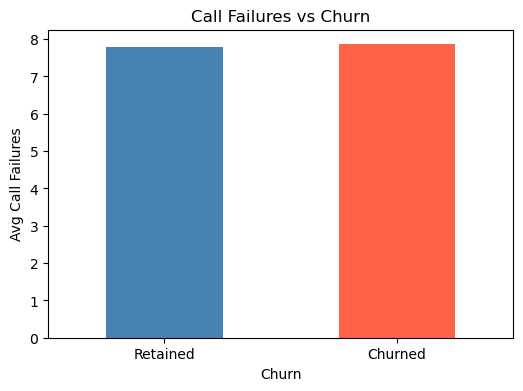

In [115]:
cc.groupby('Churn')['Call  Failure'].mean().plot(kind='bar', color= ['steelblue','tomato'], figsize=(6, 4))
plt.title('Call Failures vs Churn')
plt.xticks([0, 1], ['Retained', 'Churned'], rotation=0)
plt.ylabel('Avg Call Failures')
plt.show();

### Finding:

Retained customers average 7.79 call failures and churned customers average 7.86. The difference is so small it is essentially meaningless, and the two bars in the chart look almost identical. H0 is accepted. Call failures alone do not drive churn in this dataset. Customers seem to tolerate network issues. What pushes them over the edge is poor complaint handling, not the technical failures themselves.

---
## Step 14: Subscription Length vs Churn

It is commonly assumed that customers who have been with a company longer are less likely to leave. This analysis tests whether that assumption holds true here.

H0: Customers with longer subscriptions are less likely to churn.

H1: Subscription length has no meaningful impact on whether a customer churns.

In [116]:
# Average subscription length in months for retained vs churned customers
cc.groupby('Churn')['Subscription  Length'].mean()

Churn
0.0    32.595674
1.0    31.683857
Name: Subscription  Length, dtype: float64

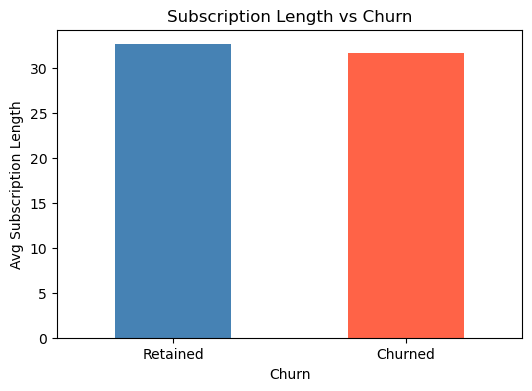

In [117]:
cc.groupby('Churn')['Subscription  Length'].mean().plot(
    kind='bar',color=['steelblue', 'tomato'],figsize=(6, 4))
plt.title('Subscription Length vs Churn')
plt.xticks([0, 1], ['Retained', 'Churned'], rotation=0)
plt.ylabel('Avg Subscription Length')
plt.show()

### Finding:

Retained customers average 32.59 months and churned customers average 31.68 months — a difference of less than one month. The two bars are nearly the same height. H0 is accepted. How long a customer has been subscribed does not protect them from churning. This is an important lesson: loyalty built on time alone is not enough. If the service experience is poor, even long-standing customers will leave.

---
## Step 15: Usage Behavior vs Churn

If churned customers were already using the service much less before they left, that pattern could serve as an early warning signal for the business to act on.

H0: Churned and retained customers have similar usage levels across all channels.

H1: Churned customers consistently show lower usage than retained customers across calls, frequency, and SMS.

In [118]:
# Average seconds of use for retained vs churned customers
cc.groupby('Churn')['Seconds of Use'].mean()

Churn
0.0    5069.588186
1.0    1648.661435
Name: Seconds of Use, dtype: float64

In [119]:
# Average values across all three usage metrics grouped by churn status
cc.groupby('Churn')[['Seconds of Use', 'Frequency of use','Frequency of SMS']].mean()

,Seconds of Use,Frequency of use,Frequency of SMS
Churn,,,
0.0,5069.588186,77.866473,84.353577
1.0,1648.661435,30.697309,16.849776


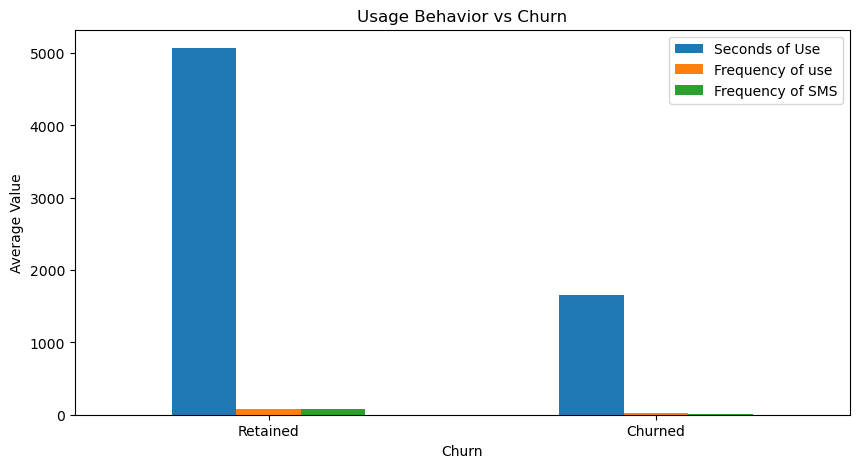

In [120]:
cc.groupby('Churn')[['Seconds of Use', 'Frequency of use','Frequency of SMS']].mean().plot(
    kind='bar',figsize=(10, 5))
plt.title('Usage Behavior vs Churn')
plt.xticks([0, 1], ['Retained', 'Churned'], rotation=0)
plt.ylabel('Average Value')
plt.show()

### Finding:

Across every single usage metric, churned customers used the service far less than those who stayed. Churned customers used 3 times fewer call seconds, made calls 2.5 times less frequently, and sent 5 times fewer SMS messages. The chart shows a dramatic drop across all three bars when moving from the retained group to the churned group. H0 is rejected. Low engagement is the clearest early warning signal of a customer who is about to leave. If the business can identify customers showing declining usage and reach out to them before they make the decision to leave, it could prevent a significant portion of churn.

---
## Step 16: Charge Amount vs Churn

Customers on lower-priced plans may feel less committed to the service, making them easier to lose to a competitor.

H0: Charge amount has no relationship with whether a customer churns.

H1: Customers who pay lower charge amounts are more likely to churn.

In [121]:
# Average charge amount for retained vs churned customers
cc.groupby('Churn')['Charge  Amount'].mean()

Churn
0.0    1.109401
1.0    0.248879
Name: Charge  Amount, dtype: float64

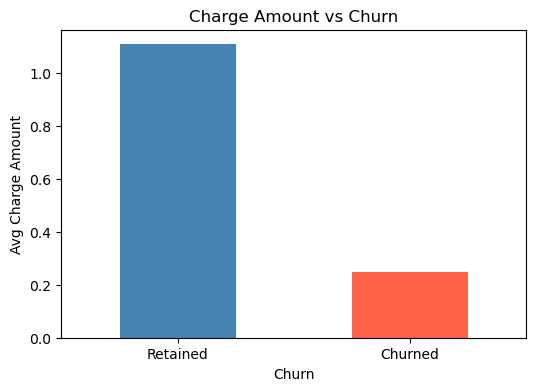

In [122]:
cc.groupby('Churn')['Charge  Amount'].mean().plot(
    kind='bar',color=['steelblue', 'tomato'],figsize=(6, 4))
plt.title('Charge Amount vs Churn')
plt.xticks([0, 1], ['Retained', 'Churned'], rotation=0)
plt.ylabel('Avg Charge Amount')
plt.show()

### Finding:

Retained customers average a charge of 1.11 while churned customers average only 0.25. Customers who stayed are paying four times more than those who left. H0 is rejected. Lower charge amount is clearly associated with higher churn. Customers on cheaper plans tend to have less skin in the game and are more willing to switch. The business should consider adding value for low-charge customers through personalized offers or upgrades to bring them up to a higher level of commitment before they decide to leave.

---
## Conclusion

This project completed a full Exploratory Data Analysis on a telecom customer churn dataset with 2,851 customers and 13 features.

---

### Key Findings

The overall churn rate is 15.6 percent, which is alarming and well above the acceptable threshold.

Complaints are the single most powerful churn driver — 82 percent of customers who raised a complaint ended up leaving.

Customer inactivity is the strongest predictive signal — nearly half of all inactive customers churned.

Churned customers consistently showed 3 to 5 times lower engagement across calls, frequency, and SMS compared to those who stayed.

Customers on Tariff Plan 1 churned at 6 times the rate of those on Plan 2, suggesting a serious problem with that plan's pricing or value.

The business has lost a total of 27,784 in customer value due to churn, with retained customers being worth 3 times more on average.

Age Group 3 had the highest absolute number of churned customers and is the most important retention target.

Customers paying lower charge amounts are 4 times more likely to churn, indicating lower financial commitment to the service.

Call failures and subscription length had almost no measurable impact on whether a customer churned.

---

### Business Recommendations

Fix the complaint resolution process. With 82 percent of complainers churning, even a modest improvement in how complaints are handled could have a significant impact on the overall churn rate.

Re-engage inactive customers as early as possible. Nearly half of them will leave if nothing is done. A targeted campaign with a special offer could bring many of them back before they make the final decision to go.

Review Tariff Plan 1. The churn rate on this plan is 6 times higher than Plan 2. The business needs to understand whether the issue is pricing, coverage, features, or customer service, and fix it urgently.

Build an early warning system based on usage data. Customers who are about to churn use the service far less than those who stay. Flagging customers with a sharp drop in usage could give the business enough time to intervene and retain them.

Run targeted retention offers for Age Group 3 and low-charge-amount customers. These two segments have consistently shown the highest churn risk and would benefit most from proactive outreach.